In [1]:
from typing import cast

from datasets import Dataset
from datasets import load_dataset as hf_load

cppe5_train = cast(Dataset, hf_load("rishitdagli/cppe-5", split="train"))

/builds/jatic/aria/dataeval-flow/.nox/docs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

data_path = Path("./data/cppe5/train")


def write_imagefolder(hf_dataset: Dataset, root: Path) -> None:
    """Write a HuggingFace object-detection split in the ImageFolder convention."""
    root.mkdir(parents=True, exist_ok=True)
    for stale in root.glob("metadata.*"):  # a leftover metadata file is read alongside the new one
        stale.unlink()

    file_names = []
    for seq, example in enumerate(hf_dataset):
        file_name = f"{seq:05d}.jpg"
        example["image"].convert("RGB").save(root / file_name, quality=95)
        file_names.append(file_name)

    # Carry the source `objects` column through untouched so its `category` ClassLabel — the
    # Coverall/Face_Shield/... name table — lands in the parquet features schema.
    metadata = hf_dataset.remove_columns(["image", "image_id", "width", "height"]).add_column("file_name", file_names)
    metadata.to_parquet(root / "metadata.parquet")


write_imagefolder(cppe5_train, data_path)

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format: 100%|██████████| 1/1 [00:00<00:00, 422.64ba/s]

In [3]:
from dataeval.config import set_max_processes

from dataeval_flow.config import (
    BoVWExtractorConfig,
    DataCleaningTaskConfig,
    DataCleaningWorkflowConfig,
    HuggingFaceDatasetConfig,
    PipelineConfig,
    SourceConfig,
    ViewConfig,
    ViewOperation,
)
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.cleaning.params import DataCleaningHealthThresholds

set_max_processes(8)  # Set max processes for parallel execution (adjust as needed)

advisory_workflow = DataCleaningWorkflowConfig(
    name="cppe5_advisory_clean",
    mode="advisory",
    outlier_method="adaptive",  # Use adaptive thresholding for outliers
    outlier_threshold=3.5,
    outlier_flags=["dimension", "pixel", "visual"],  # All image stat groups
    outlier_cluster_threshold=3.5,  # Cluster-based detection in embedding space (requires extractor).
    outlier_cluster_algorithm="hdbscan",
    outlier_n_clusters=5,  # CPPE-5 has 5 classes
    duplicate_cluster_sensitivity=0.5,  # Duplicate detection — hash-based plus cluster-based.
    duplicate_cluster_algorithm="hdbscan",
    duplicate_n_clusters=5,
    health_thresholds=DataCleaningHealthThresholds(
        exact_duplicates=0.0,  # No exact duplicates allowed (default)
        near_duplicates=5.0,  # Up to 5% near duplicates before warning (default)
        image_outliers=5.0,  # Relaxed from 3% default — CPPE-5 has diverse images
        target_outliers=10.0,  # Relaxed from 3% default — object detection has annotation variance
        classwise_outliers=12.0,  # Relaxed from 3% default — some classes are visually diverse
        class_label_imbalance=5.0,  # CPPE-5 has moderate imbalance (default)
    ),
)

task = DataCleaningTaskConfig(
    name="cppe5_clean",
    workflow="cppe5_advisory_clean",
    sources="cppe5_src",
    extractor="bovw_ext",
)

# Build the full pipeline config — datasets, sources, extractors, views, workflows, and tasks
config = PipelineConfig(
    datasets=[
        HuggingFaceDatasetConfig(name="cppe5_train", path=str(data_path), task="object_detection"),
    ],
    views=[
        ViewConfig(name="first500", operations=[ViewOperation(type="Limit", params={"size": 500})]),
    ],
    sources=[
        SourceConfig(name="cppe5_src", dataset="cppe5_train", view="first500"),
    ],
    extractors=[
        BoVWExtractorConfig(name="bovw_ext", vocab_size=512, batch_size=32),
    ],
    workflows=[advisory_workflow],
    tasks=[task],
)

In [4]:
result = run_task(task, config, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/cleaning/workflow.py:277: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


In [5]:
print(result.report())


  DATA CLEANING COMPLETE. DATASET: 500 ITEMS. MODE: ADVISORY.
  Timestamp:    2026-09-04T07:20:28.928638+00:00
  Duration:     10.41s
  Source:       cppe5_src (cppe5_train[first500])
  Model:        bovw_ext (bovw)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  Image Outliers ...................................... 45 images (9.0%)  [!!]
  Target Outliers ................................... 199 targets (9.1%)  [..]
  Classwise Outliers ... worst: Coverall (13.2%), 1/5 classes over 12.0%  [..]
  Duplicates ............................ 2 exact (0.4%), 28 near (5.6%)  [!!]
  Label Distribution ............. 5 classes, 500 items, imbalance 3.4:1  [..]

  Health: 2 warning(s) [!!] — review flagged findings

  IMAGE OUTLIERS                                                45 images (9.0%)
  45 images (9.0%) flagged as outliers.

  Metric    Count
  --------  -----
  size         18
  zeros        15
  height       13
  kurtosis     12


In [6]:
assert result.dataset is not None
ds = result.dataset

In [7]:
raw = result.data.raw

# Collect unique outlier image indices, grouped by image
outlier_issues = raw.img_outliers["issues"]
outlier_grouped: dict[int, list[str]] = {
    idx: [i["metric_name"] for i in outlier_issues if i["item_index"] == idx]
    for idx in {i["item_index"] for i in outlier_issues}
}

outlier_indices = sorted(outlier_grouped)
print(f"Image outliers: {len(outlier_indices)} images flagged, {len(outlier_issues)} total flags")

Image outliers: 45 images flagged, 70 total flags


Outlier sample — flagged metrics per image:
  Image    60: zeros
  Image    62: zeros
  Image    66: zeros
  Image    95: kurtosis
  Image   103: size, width, height
  Image   110: kurtosis
  Image   114: kurtosis
  Image   127: zeros
  Image   144: size, height


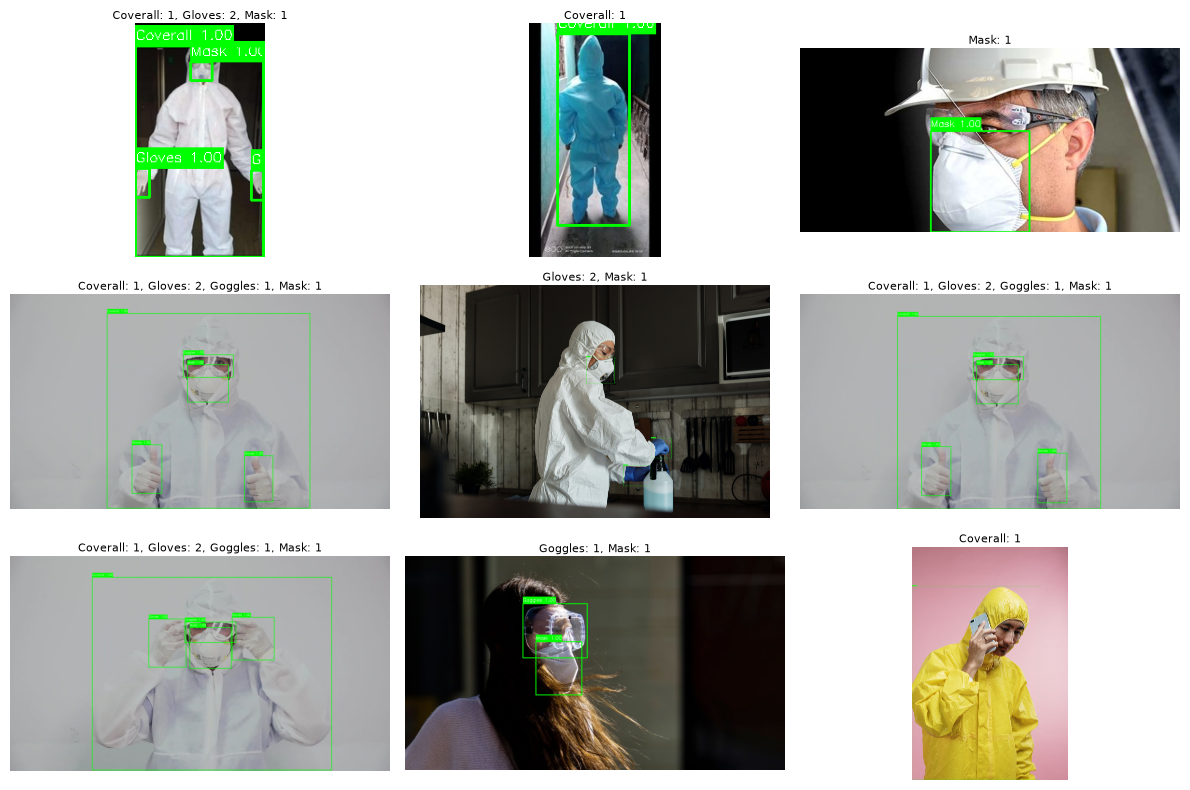

In [8]:
from dataeval_plots import plot

# Show a sample of outlier images (first 9)
if outlier_indices:
    sample = outlier_indices[:9]
    print("Outlier sample — flagged metrics per image:")
    for idx in sample:
        print(f"  Image {idx:>5d}: {', '.join(outlier_grouped[idx])}")
    _ = plot(ds, indices=sample, images_per_row=3, figsize=(12, 8), show_labels=True)

In [9]:
exact_groups = raw.duplicates["items"].get("exact", [])
near_groups = raw.duplicates["items"].get("near", [])

print(f"Exact duplicate groups: {len(exact_groups)}")
print(f"Near  duplicate groups: {len(near_groups)}")

Exact duplicate groups: 1
Near  duplicate groups: 11



Exact group 0: indices [133, 487]


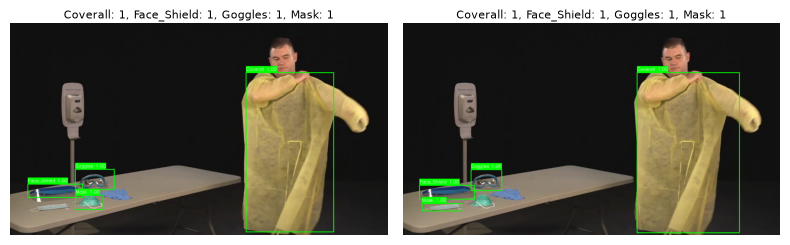

In [10]:
# Plot exact duplicate groups (if any)
for i, group in enumerate(exact_groups[:3]):
    indices = group if isinstance(group, list) else group["indices"]
    print(f"\nExact group {i}: indices {indices}")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)


Near group 0: indices [59, 81, 176]  (methods: ['phash'])

Near group 1: indices [72, 101]  (methods: ['phash'])



Near group 2: indices [95, 110, 398]  (methods: ['dhash', 'phash'])


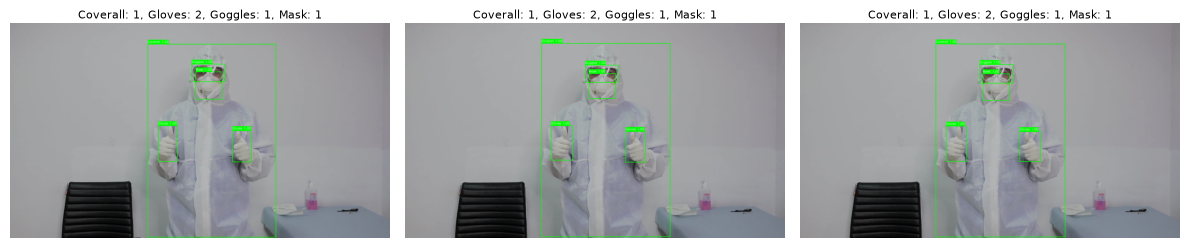

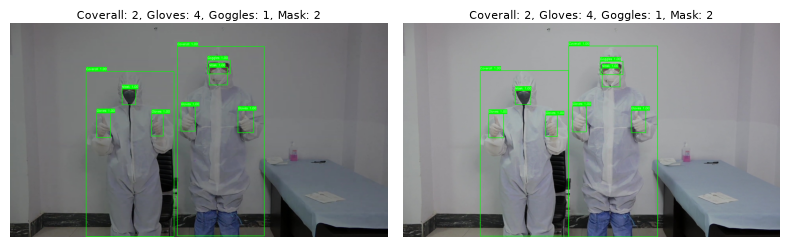

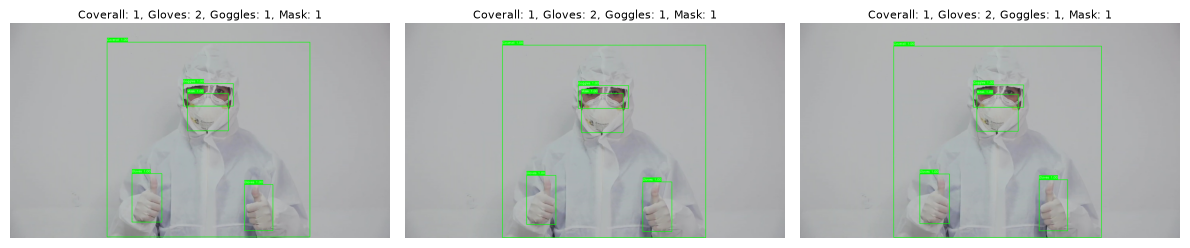

In [11]:
# Plot near duplicate groups (if any)
for i, group in enumerate(near_groups[:3]):
    indices = group["indices"]
    methods = group.get("methods", [])
    print(f"\nNear group {i}: indices {indices}  (methods: {methods})")
    _ = plot(ds, indices=indices, images_per_row=len(indices), figsize=(4 * len(indices), 4), show_labels=True)

In [12]:
# Define a preparatory pipeline — same params but mode="preparatory"
# Copy the advisory workflow and change name + mode
prep_workflow = advisory_workflow.model_copy(
    update={"name": "cppe5_prep_clean", "mode": "preparatory"},
)

task_prep = DataCleaningTaskConfig(
    name="cppe5-clean-prep",
    workflow="cppe5_prep_clean",
    sources="cppe5_src",
    extractor="bovw_ext",
)

config_prep = PipelineConfig(
    datasets=config.datasets,
    views=config.views,
    sources=config.sources,
    extractors=config.extractors,
    workflows=[advisory_workflow, prep_workflow],
    tasks=[task_prep],
)

result_prep = run_task(task_prep, config_prep, cache_dir=Path("./cache"))

/builds/jatic/aria/dataeval-flow/src/dataeval_flow/workflows/cleaning/workflow.py:277: UserWarning: `height` and `width` were binned automatically ('uniform_width') because no bins were declared. The bin count is derived from the data, so it is not stable across samples and the same factor measured twice may not be comparable. Declare cutoffs with continuous_factor_bins={"height": [...]} to control this.
  td = metadata.rows_at(metadata.label_level).select("item_index", "target_index", "class_label")


In [13]:
if not result_prep.success:
    print(f"Workflow failed: {result_prep.errors}")
assert result_prep.success

In [14]:
meta = result_prep.metadata
print(f"Mode: {meta.mode}")
print(f"Flagged for removal : {meta.removed_count}")
print(f"Retained (clean)    : {len(meta.clean_indices)}")

if meta.flagged_indices:
    print(f"\nFirst 20 flagged indices: {meta.flagged_indices[:20]}")

Mode: preparatory
Flagged for removal : 59
Retained (clean)    : 441

First 20 flagged indices: [60, 62, 66, 81, 95, 101, 103, 110, 114, 127, 144, 164, 176, 193, 194, 196, 201, 202, 213, 217]


In [15]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:500] + "\n...")

JSON output: 74064 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-09-04T07:20:28.928638Z",
    "dataset_id": "cppe5_train",
    "label_source": "huggingface",
    "model_id": "bovw_ext (bovw)",
    "preprocessor_id": null,
    "selection_id": "first500",
    "source_descriptions": [
      "cppe5_src (cppe5_train[first500])"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "cppe5_src",
          "dataset": "cppe5_train",
          "dataset_config": {
            "format
...
